# Experiment 3 — TimeGAN Sample-Size Saturation Study

**Question:** for each QUIDA dataset, how many samples can one trained TimeGAN generate before extra samples
stop adding value (fidelity plateaus and the generator begins repeating itself)?

**Method (no self-consuming loop).** For each dataset and each random seed: train the TimeGAN **once** on the
real training split, then **generate at increasing sizes** (1x, 2x, 3x, 5x, 8x the real count) from that
single fixed model. Every generated set is scored against the same real reference. Results are **averaged
over seeds** so the recommended size is a stable knee, not an artifact of one split.

**Metrics:** MMD, Wasserstein, Correlation Difference, OCSVM coverage gap + Score Gap, Variance Increase,
and Density/Coverage (precision-recall for generative models). Distribution/geometry metrics are computed
in a shared standardized-PCA embedding of the real data; per-channel metrics (Wasserstein, correlation)
in standardized original space.

**Output:** per-dataset metric-vs-size tables and curves (knee marked), PCA overlays across sizes, and a
recommended sample size per dataset, plus a cross-dataset summary.

> This is the TimeGAN counterpart of Experiment 2 (Beta-VAE). Same sweep, same metrics, same visuals,
> same recommendation logic and the same reversible `Prep` pipeline — only the generator differs. Outputs
> go to `timegan_size_study/` so the two studies sit side by side for the planned VAE-vs-TimeGAN comparison
> (`cross_dataset_summary.csv` has matching columns).

> Note: a fixed TimeGAN does not lose per-sample quality as you draw more; what saturates is the *marginal
> value* of each extra sample. So the deliverable is a **saturation point**, not a cliff.

## 1. Import libraries

In [1]:
from __future__ import annotations
import os, json, pickle, random, warnings, time
from pathlib import Path
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.svm import OneClassSVM
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import rbf_kernel
from scipy.spatial.distance import cdist, pdist
from scipy.stats import wasserstein_distance

import tensorflow as tf
try:
    import keras
    from keras import layers
except ImportError:
    from tensorflow import keras
    from tensorflow.keras import layers

_saving = getattr(keras, "saving", None)
def _pick(fn): return getattr(_saving, fn, None) or getattr(keras.utils, fn, None)
register_keras_serializable = _pick("register_keras_serializable") or (lambda **k: (lambda c: c))
serialize_keras_object   = _pick("serialize_keras_object")
deserialize_keras_object = _pick("deserialize_keras_object")

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("TensorFlow:", tf.__version__, "| Keras:", keras.__version__,
      "| GPUs:", tf.config.list_physical_devices("GPU") or "none (CPU)")

TensorFlow: 2.16.1 | Keras: 3.3.3 | GPUs: none (CPU)


## 2. Configuration

In [ ]:
@dataclass
class Config:
    # Dataset provided by the professor in Vocareum
    data_dir: Path = field(
        default_factory=lambda: (Path.cwd() / "../../exp_3").resolve()
    )

    # Generated results stay inside the current EXP_3 directory
    output_dir: Path = field(
        default_factory=lambda: Path.cwd() / "timegan_same_params"
    )

    dataset_glob: str = "*_raw.npy"
    datasets: dict | None = field(
        default_factory=lambda: {
            "X_imu_radar": "X_imu_radar_raw.npy"
        }
    )

    seed: int = 42
    val_split: float = 0.2

    # --- sample-size sweep ---
    multipliers: tuple = (1, 2, 3, 5, 6, 7, 8, 9, 10)
    n_seeds: int = 3
    recommend_tol: float = 0.05

    # --- preprocessing (reversible, shared with the VAE study) ---
    use_signed_log: bool = True
    drop_constant: bool = True
    const_eps: float = 1e-8
    use_pca: bool = True
    pca_components: int = 32

    # --- model (TimeGAN: 5 GRU nets) ---
    hidden_dim: int = 24
    num_layers: int = 3
    gamma: float = 1.0

    # --- training ---
    embedding_epochs: int = 200
    supervised_epochs: int = 150
    joint_epochs: int = 250
    batch_size: int = 32
    learning_rate: float = 1e-3
    early_stopping_patience: int = 30

    # --- evaluation ---
    emb_max_dim: int = 30
    ocsvm_nu: float = 0.1
    dc_k: int = 5
    feat_cap: int = 150
    mmd_cap: int = 800
    pca_plot: bool = True


CFG = Config()

CFG.output_dir.mkdir(parents=True, exist_ok=True)

print("Data:", CFG.data_dir)
print("Output:", CFG.output_dir)
print(
    "Multipliers:", CFG.multipliers,
    "| seeds:", CFG.n_seeds
)

Data: C:\Users\mabideen\Downloads\Data_Augmentation\exp_3
Output: c:\Users\mabideen\Downloads\Data_Augmentation\Stage_2_Data_generation\exp_3\timegan_size_same_params
Multipliers: (1, 2, 3, 5, 6, 7, 8, 9, 10) | seeds: 3


In [3]:
def set_seeds(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed); random.seed(seed); np.random.seed(seed)
    try: keras.utils.set_random_seed(seed)
    except Exception: tf.random.set_seed(seed)
set_seeds(CFG.seed)

## 3. Load the four datasets

In [4]:
def _clean_name(fn):
    s = Path(fn).stem; return s[:-4] if s.endswith("_raw") else s

def discover_datasets(cfg):
    if cfg.datasets:
        items = list(cfg.datasets.items())
        miss = [str(cfg.data_dir/f) for _,f in items if not (cfg.data_dir/f).exists()]
        if miss: raise FileNotFoundError("Missing: " + ", ".join(miss))
    else:
        files = sorted(cfg.data_dir.glob(cfg.dataset_glob), key=lambda q:(q.name.count("_"), q.name))
        if not files: raise FileNotFoundError(f"No files matching {cfg.dataset_glob!r} in {cfg.data_dir}")
        items = [(_clean_name(q.name), q.name) for q in files]
    data={}
    for name,fname in items:
        data[name]=np.load(cfg.data_dir/fname, allow_pickle=False).astype(np.float32)
        print(f"  {name:16s} <- {fname:26s} {data[name].shape}")
    return data
RAW = discover_datasets(CFG)

  X_imu_radar      <- X_imu_radar_raw.npy        (99, 32, 1137)


## 4. Data validation

In [5]:
def validate_dataset(name, X, cfg):
    assert X.ndim==3, f"{name}: need (N,T,F), got {X.shape}"
    N,T,F=X.shape
    n_nan,n_inf=int(np.isnan(X).sum()),int(np.isinf(X).sum())
    if n_nan or n_inf:
        X=np.where(np.isfinite(X),X,np.nan)
        fm=np.nan_to_num(np.nanmean(X.reshape(-1,F),axis=0)); ii=np.where(~np.isfinite(X)); X[ii]=np.take(fm,ii[2])
        print(f"  ! {name}: imputed {n_nan} NaN / {n_inf} Inf")
    nconst=int((np.ptp(X.reshape(-1,F).astype(np.float64),axis=0)<=cfg.const_eps).sum())
    print(f"  {name:16s} N={N} T={T} F={F} const_cols={nconst} min={X.min():+.1f} max={X.max():+.1f}")
    return X.astype(np.float32)
RAW={n:validate_dataset(n,X,CFG) for n,X in RAW.items()}

  X_imu_radar      N=99 T=32 F=1137 const_cols=294 min=-73.4 max=+1523.0


## 5. Reversible preprocessing (`Prep`)

Identical pipeline to the VAE study so wide datasets stay tractable and both experiments compare like-for-like: signed-log -> drop constant columns -> optional PCA to `pca_components` dims -> MinMax to [0,1].

In [6]:
def _slog(x): return np.sign(x)*np.log1p(np.abs(x))
def _islog(y): return np.sign(y)*np.expm1(np.abs(y))

class Prep:
    def __init__(self,cfg): self.cfg=cfg
    def fit(self,X):
        N,T,F=X.shape; self.T,self.F_full=T,F
        o=X.reshape(-1,F).astype(np.float64)
        self.keep=(np.ptp(o,axis=0)>self.cfg.const_eps) if self.cfg.drop_constant else np.ones(F,bool)
        lg=_slog(o) if self.cfg.use_signed_log else o
        self.const=lg.mean(0); kept=lg[:,self.keep]
        if self.cfg.use_pca and kept.shape[1]>self.cfg.pca_components:
            k=min(self.cfg.pca_components,kept.shape[1],len(kept)-1)
            self.pca=PCA(k,random_state=self.cfg.seed).fit(kept); comps=self.pca.transform(kept)
        else: self.pca=None; comps=kept
        self.scaler=MinMaxScaler().fit(comps); self.K=comps.shape[1]; self.n_dropped=int((~self.keep).sum())
        return self
    def transform(self,X):
        n=len(X); lg=X.reshape(-1,self.F_full).astype(np.float64)
        if self.cfg.use_signed_log: lg=_slog(lg)
        kept=lg[:,self.keep]; comps=self.pca.transform(kept) if self.pca is not None else kept
        return self.scaler.transform(comps).reshape(n,self.T,self.K).astype("float32")
    def inverse(self,Xs):
        n=len(Xs); comps=self.scaler.inverse_transform(Xs.reshape(-1,self.K))
        kept=self.pca.inverse_transform(comps) if self.pca is not None else comps
        full=np.zeros((len(kept),self.F_full)); full[:,self.keep]=kept
        if self.n_dropped: full[:,~self.keep]=self.const[~self.keep]
        if self.cfg.use_signed_log: full=_islog(full)
        return full.reshape(n,self.T,self.F_full).astype("float32")

def split_data(X,cfg,seed):
    return train_test_split(X,test_size=cfg.val_split,random_state=seed,shuffle=True)

## 6. Build the TimeGAN (5 GRU nets, native Keras 3)

Embedder `E: X->H`, Recovery `R: H->X~`, Generator `G: Z->E^`, Supervisor `S: H->H_next`, Discriminator `D: H->logit`. All in the `[0,1]` prep space (sigmoid outputs); the discriminator emits per-timestep logits. Generation is `Z -> G -> S -> R`.

In [7]:
def _gru_stack(x, hidden, n_layers):
    for _ in range(max(1, n_layers)):
        x = layers.GRU(hidden, return_sequences=True)(x)
    return x

def build_embedder(T, K, hidden, n_layers):
    xi = keras.Input((T, K))
    x  = _gru_stack(xi, hidden, n_layers)
    return keras.Model(xi, layers.Dense(hidden, activation="sigmoid")(x), name="embedder")

def build_recovery(T, K, hidden, n_layers):
    hi = keras.Input((T, hidden))
    x  = _gru_stack(hi, hidden, n_layers)
    return keras.Model(hi, layers.Dense(K, activation="sigmoid")(x), name="recovery")

def build_generator(T, z_dim, hidden, n_layers):
    zi = keras.Input((T, z_dim))
    x  = _gru_stack(zi, hidden, n_layers)
    return keras.Model(zi, layers.Dense(hidden, activation="sigmoid")(x), name="generator")

def build_supervisor(T, hidden, n_layers):
    hi = keras.Input((T, hidden))
    x  = _gru_stack(hi, hidden, max(1, n_layers-1))
    return keras.Model(hi, layers.Dense(hidden, activation="sigmoid")(x), name="supervisor")

def build_discriminator(T, hidden, n_layers):
    hi = keras.Input((T, hidden))
    x  = _gru_stack(hi, hidden, n_layers)
    return keras.Model(hi, layers.Dense(1)(x), name="discriminator")   # per-timestep logits


class TimeGAN:
    """Native Keras-3 TimeGAN: 5 GRU sub-nets + 3-phase manual GradientTape training."""
    def __init__(self, T, K, cfg):
        self.T, self.K, self.z_dim = T, K, K
        h, L = cfg.hidden_dim, cfg.num_layers
        self.embedder      = build_embedder(T, K, h, L)
        self.recovery      = build_recovery(T, K, h, L)
        self.generator     = build_generator(T, self.z_dim, h, L)
        self.supervisor    = build_supervisor(T, h, L)
        self.discriminator = build_discriminator(T, h, L)
        self.gamma = float(cfg.gamma)
        self.bce = keras.losses.BinaryCrossentropy(from_logits=True)
        lr = cfg.learning_rate
        # one optimizer per fixed variable set (Keras 3 builds each optimizer once)
        self.ae_opt = keras.optimizers.Adam(lr, clipnorm=1.0)   # embedder + recovery
        self.s_opt  = keras.optimizers.Adam(lr, clipnorm=1.0)   # supervisor only (phase 2)
        self.g_opt  = keras.optimizers.Adam(lr, clipnorm=1.0)   # generator + supervisor (phase 3)
        self.d_opt  = keras.optimizers.Adam(lr, clipnorm=1.0)   # discriminator

    # ---- phase 1: reconstruction (embedder + recovery) ----
    @tf.function(reduce_retracing=True)
    def train_embedder(self, X):
        with tf.GradientTape() as tape:
            H = self.embedder(X, training=True); Xt = self.recovery(H, training=True)
            E_loss_T0 = tf.reduce_mean(tf.square(X - Xt))
            E_loss0 = 10.0 * tf.sqrt(E_loss_T0 + 1e-8)
        v = self.embedder.trainable_weights + self.recovery.trainable_weights
        self.ae_opt.apply_gradients(zip(tape.gradient(E_loss0, v), v))
        return E_loss_T0

    # ---- phase 2: temporal supervised loss (generator + supervisor) ----
    @tf.function(reduce_retracing=True)
    def train_supervisor(self, X):
        with tf.GradientTape() as tape:
            H = self.embedder(X, training=True); Hs = self.supervisor(H, training=True)
            S_loss = tf.reduce_mean(tf.square(H[:,1:,:] - Hs[:,:-1,:]))
        v = self.supervisor.trainable_weights
        self.s_opt.apply_gradients(zip(tape.gradient(S_loss, v), v))
        return S_loss

    # ---- phase 3a: generator (generator + supervisor) ----
    @tf.function(reduce_retracing=True)
    def train_generator(self, X, Z):
        with tf.GradientTape() as tape:
            H  = self.embedder(X, training=True); Hs = self.supervisor(H, training=True)
            S_loss = tf.reduce_mean(tf.square(H[:,1:,:] - Hs[:,:-1,:]))
            E_hat = self.generator(Z, training=True); H_hat = self.supervisor(E_hat, training=True)
            X_hat = self.recovery(H_hat, training=True)
            Yf  = self.discriminator(H_hat, training=True)
            Yfe = self.discriminator(E_hat, training=True)
            G_U   = self.bce(tf.ones_like(Yf),  Yf)
            G_U_e = self.bce(tf.ones_like(Yfe), Yfe)
            V1 = tf.reduce_mean(tf.abs(tf.sqrt(tf.math.reduce_variance(X_hat,axis=0)+1e-6)
                                       - tf.sqrt(tf.math.reduce_variance(X,axis=0)+1e-6)))
            V2 = tf.reduce_mean(tf.abs(tf.reduce_mean(X_hat,axis=0) - tf.reduce_mean(X,axis=0)))
            G_loss = G_U + self.gamma*G_U_e + 100.0*tf.sqrt(S_loss+1e-8) + 100.0*(V1+V2)
        v = self.generator.trainable_weights + self.supervisor.trainable_weights
        self.g_opt.apply_gradients(zip(tape.gradient(G_loss, v), v))
        return G_loss, S_loss

    # ---- phase 3b: embedder joint (embedder + recovery, with supervised term) ----
    @tf.function(reduce_retracing=True)
    def train_embedder_joint(self, X):
        with tf.GradientTape() as tape:
            H = self.embedder(X, training=True); Xt = self.recovery(H, training=True)
            E_loss_T0 = tf.reduce_mean(tf.square(X - Xt)); E_loss0 = 10.0*tf.sqrt(E_loss_T0+1e-8)
            Hs = self.supervisor(H, training=True)
            S_loss = tf.reduce_mean(tf.square(H[:,1:,:] - Hs[:,:-1,:]))
            E_loss = E_loss0 + 0.1*S_loss
        v = self.embedder.trainable_weights + self.recovery.trainable_weights
        self.ae_opt.apply_gradients(zip(tape.gradient(E_loss, v), v))
        return E_loss_T0

    # ---- phase 3c: discriminator ----
    @tf.function(reduce_retracing=True)
    def _disc_loss(self, X, Z, training):
        H = self.embedder(X, training=False)
        E_hat = self.generator(Z, training=False); H_hat = self.supervisor(E_hat, training=False)
        Yr, Yf, Yfe = (self.discriminator(H, training=training),
                       self.discriminator(H_hat, training=training),
                       self.discriminator(E_hat, training=training))
        return (self.bce(tf.ones_like(Yr),Yr) + self.bce(tf.zeros_like(Yf),Yf)
                + self.gamma*self.bce(tf.zeros_like(Yfe),Yfe))

    @tf.function(reduce_retracing=True)
    def train_discriminator(self, X, Z):
        with tf.GradientTape() as tape:
            D_loss = self._disc_loss(X, Z, training=True)
        v = self.discriminator.trainable_weights
        self.d_opt.apply_gradients(zip(tape.gradient(D_loss, v), v))
        return D_loss

    def disc_loss_only(self, X, Z):
        return float(self._disc_loss(X, Z, training=False))

    def val_recon(self, Xval):
        H = self.embedder(Xval, training=False); Xt = self.recovery(H, training=False)
        return float(tf.reduce_mean(tf.square(Xval - Xt)))

def build_timegan(T, K, cfg):
    return TimeGAN(T, K, cfg)

## 7. Train the TimeGAN (once per seed)

Three phases run in sequence: (1) autoencoder pretraining with val early-stopping, (2) temporal supervisor, (3) adversarial joint training (2 generator+embedder steps then a gated discriminator step per batch). `hist.history['loss']` holds the per-epoch joint generator loss so it slots into the same sweep bookkeeping as the VAE.

In [8]:
class TGHistory:
    def __init__(self, history): self.history = history

def _iter_batches(X, bs, rng):
    idx = rng.permutation(len(X))
    for i in range(0, len(X), bs):
        b = idx[i:i+bs]
        if len(b) >= 2: yield X[b]

def _noise(n, T, z_dim, rng):
    return rng.uniform(0.0, 1.0, size=(n, T, z_dim)).astype("float32")

def train_timegan(tgan, Xtr, Xval, cfg):
    Xtr = Xtr.astype("float32"); Xval = Xval.astype("float32")
    T, z = tgan.T, tgan.z_dim
    bs = min(cfg.batch_size, max(2, len(Xtr)))
    rng = np.random.default_rng(cfg.seed)
    hist = {"embedding_loss": [], "supervised_loss": [], "g_loss": [], "d_loss": [], "loss": []}

    # phase 1 - embedding network (val early stop, restore best)
    best, best_w, wait = np.inf, None, 0
    for ep in range(cfg.embedding_epochs):
        el = [float(tgan.train_embedder(xb)) for xb in _iter_batches(Xtr, bs, rng)]
        hist["embedding_loss"].append(float(np.mean(el)) if el else np.nan)
        v = tgan.val_recon(Xval)
        if v < best - 1e-5:
            best, wait = v, 0
            best_w = (tgan.embedder.get_weights(), tgan.recovery.get_weights())
        else:
            wait += 1
            if wait >= cfg.early_stopping_patience: break
    if best_w is not None:
        tgan.embedder.set_weights(best_w[0]); tgan.recovery.set_weights(best_w[1])

    # phase 2 - supervised loss only
    for ep in range(cfg.supervised_epochs):
        sl = [float(tgan.train_supervisor(xb)) for xb in _iter_batches(Xtr, bs, rng)]
        hist["supervised_loss"].append(float(np.mean(sl)) if sl else np.nan)

    # phase 3 - joint adversarial training
    for ep in range(cfg.joint_epochs):
        gl, dl = [], []
        for xb in _iter_batches(Xtr, bs, rng):
            n = len(xb)
            for _ in range(2):
                g, _s = tgan.train_generator(xb, _noise(n, T, z, rng))
                tgan.train_embedder_joint(xb)
            zb = _noise(n, T, z, rng)
            d0 = tgan.disc_loss_only(xb, zb)
            d  = float(tgan.train_discriminator(xb, zb)) if d0 > 0.15 else d0
            gl.append(float(g)); dl.append(d)
        hist["g_loss"].append(float(np.mean(gl)) if gl else np.nan)
        hist["d_loss"].append(float(np.mean(dl)) if dl else np.nan)
        hist["loss"].append(hist["g_loss"][-1])
    return TGHistory(hist)

def generate(tgan, prep, n, cfg, latent=None):
    Z = np.random.uniform(0.0, 1.0, size=(n, tgan.T, tgan.z_dim)).astype("float32")
    E_hat = tgan.generator.predict(Z, batch_size=256, verbose=0)
    H_hat = tgan.supervisor.predict(E_hat, batch_size=256, verbose=0)
    X_hat = tgan.recovery.predict(H_hat, batch_size=256, verbose=0)
    return prep.inverse(X_hat).astype("float32")

## 8. Evaluation metrics

Distribution/geometry metrics use a shared standardized-PCA embedding of the **real** data (fit once per
dataset, so all sizes are comparable). Per-channel metrics use standardized original features. Identical to the VAE study.

In [9]:
def make_embedding(real,cfg):
    R=real.reshape(len(real),-1).astype(np.float64)
    sc=StandardScaler().fit(R); Rs=sc.transform(R)
    k=min(cfg.emb_max_dim,Rs.shape[1],max(2,len(Rs)-1))
    pca=PCA(k,random_state=cfg.seed).fit(Rs) if Rs.shape[1]>k else None
    def emb(X):
        Xs=sc.transform(X.reshape(len(X),-1).astype(np.float64))
        return pca.transform(Xs) if pca is not None else Xs
    return emb

def mmd_rbf(Re,Se,rng,cap):
    X=Re[rng.choice(len(Re),min(cap,len(Re)),replace=False)]
    Y=Se[rng.choice(len(Se),min(cap,len(Se)),replace=False)]
    med=np.median(cdist(X[:200],X[:200])); med=med if med>0 else 1.0
    return float(np.mean([rbf_kernel(X,X,g/med**2).mean()+rbf_kernel(Y,Y,g/med**2).mean()
                          -2*rbf_kernel(X,Y,g/med**2).mean() for g in (0.5,1,2)]))

def ocsvm_metrics(Re,Se,nu):
    oc=OneClassSVM(nu=nu,gamma="scale").fit(Re)
    ri=float((oc.predict(Re)==1).mean()); si=float((oc.predict(Se)==1).mean())
    return abs(ri-si), abs(float(oc.decision_function(Re).mean())-float(oc.decision_function(Se).mean()))

def density_coverage(Re,Se,k):
    k=min(k,len(Re)-1); nn=NearestNeighbors(n_neighbors=k+1).fit(Re)
    radii=nn.kneighbors(Re)[0][:,k]; inside=cdist(Se,Re)<=radii[None,:]
    return float(inside.sum()/(k*len(Se))), float(inside.any(axis=0).mean())

def variance_increase(Re,Se):
    tr=float(Re.var(0).sum()); ta=float(np.vstack([Re,Se]).var(0).sum())
    return float(ta/tr-1.0) if tr>0 else 0.0

def wasserstein_feat(real,synth,rng,cap):
    F=real.shape[-1]; idx=rng.choice(F,min(cap,F),replace=False)
    m=real.reshape(-1,F).mean(0); s=real.reshape(-1,F).std(0); s=np.where(s>1e-8,s,1.0)
    return float(np.mean([wasserstein_distance((real[...,f].ravel()-m[f])/s[f],
                                               (synth[...,f].ravel()-m[f])/s[f]) for f in idx]))

def corr_difference(real,synth,rng,cap):
    F=real.shape[-1]; idx=np.sort(rng.choice(F,min(cap,F),replace=False))
    with np.errstate(invalid="ignore",divide="ignore"):
        Cr=np.corrcoef(real.reshape(-1,F)[:,idx].T); Cs=np.corrcoef(synth.reshape(-1,F)[:,idx].T)
    return float(np.linalg.norm(np.nan_to_num(Cr)-np.nan_to_num(Cs))/len(idx))

def eval_all(real,synth,Re,Se,cfg,rng):
    cg,sg=ocsvm_metrics(Re,Se,cfg.ocsvm_nu); d,c=density_coverage(Re,Se,cfg.dc_k)
    return {"mmd":mmd_rbf(Re,Se,rng,cfg.mmd_cap),"wasserstein":wasserstein_feat(real,synth,rng,cfg.feat_cap),
            "corr_difference":corr_difference(real,synth,rng,cfg.feat_cap),"coverage_gap":cg,"score_gap":sg,
            "variance_increase":variance_increase(Re,Se),"density":d,"coverage":c}

## 9. Run the sample-size sweep

For each dataset x seed: train once, then generate & evaluate at every size. Seed-0 models are kept for
the visualisations.

In [10]:
def run_sweep(cfg):
    records=[]; embeds={}; keep_model={}
    for name,X in RAW.items():
        print(f"\n=== {name} ({X.shape}) ===")
        emb=make_embedding(X,cfg); Re=emb(X); embeds[name]={"Re":Re,"synth":{}}
        n_real=len(X); rng=np.random.default_rng(cfg.seed)
        for si in range(cfg.n_seeds):
            seed=cfg.seed+si; set_seeds(seed)
            Xtr,Xval=split_data(X,cfg,seed); prep=Prep(cfg).fit(Xtr)
            Xtr_s,Xval_s=prep.transform(Xtr),prep.transform(Xval)
            t0=time.time(); tgan=build_timegan(prep.T,prep.K,cfg); hist=train_timegan(tgan,Xtr_s,Xval_s,cfg)
            latent=None
            print(f"  seed {seed}: trained {len(hist.history['loss'])} joint ep in {time.time()-t0:.0f}s "
                  f"(K={prep.K}, dropped {prep.n_dropped})")
            for m in cfg.multipliers:
                N=int(m*n_real); synth=generate(tgan,prep,N,cfg,latent); Se=emb(synth)
                r=eval_all(X,synth,Re,Se,cfg,rng)
                records.append({"dataset":name,"multiplier":m,"N":N,"seed":seed,**r})
                if si==0: embeds[name]["synth"][N]=Se
            if si==0: keep_model[name]=(tgan,prep,latent,hist.history)
    return pd.DataFrame(records), embeds, keep_model

RESULTS, EMB, MODELS = run_sweep(CFG)
RESULTS.to_csv(CFG.output_dir/"sweep_raw.csv",index=False)
print("\nsweep done. rows:",len(RESULTS))


=== X_imu_radar ((99, 32, 1137)) ===
  seed 42: trained 250 joint ep in 353s (K=32, dropped 294)
  seed 43: trained 250 joint ep in 398s (K=32, dropped 294)
  seed 44: trained 250 joint ep in 407s (K=32, dropped 294)

sweep done. rows: 27


## 10. Aggregate + recommend the saturation size

Metrics are averaged over seeds. A composite score (mean of min-max-normalised, higher-is-better
components: -MMD, -Wasserstein, -Correlation, -coverage_gap, -score_gap, +coverage, +density) captures
both fidelity and diversity. The recommended size is the **smallest** N whose remaining composite gain to
the maximum is below `recommend_tol`.

In [11]:
MET_DIR = {"mmd":0,"wasserstein":0,"corr_difference":0,"coverage_gap":0,"score_gap":0,
           "variance_increase":1,"density":1,"coverage":1}   # 1 = higher better

def aggregate(results):
    g=results.groupby(["dataset","multiplier","N"])
    return g.mean(numeric_only=True).reset_index().drop(columns="seed"), g.std(numeric_only=True).reset_index().drop(columns="seed")

def _norm(x,hi):
    x=np.asarray(x,float); lo,h=np.nanmin(x),np.nanmax(x)
    if h-lo<1e-12: return np.ones_like(x)
    z=(x-lo)/(h-lo); return z if hi else 1-z

def recommend(sub,cfg):
    sub=sub.sort_values("N")
    comps=[_norm(sub[c].values,MET_DIR[c]) for c in ["mmd","wasserstein","corr_difference","coverage_gap","score_gap","coverage","density"]]
    C=np.mean(comps,axis=0); Cmax=C.max(); sizes=sub["N"].values; ri=len(sizes)-1
    for i in range(len(sizes)):
        if Cmax-C[i]<cfg.recommend_tol: ri=i; break
    return C, int(sizes[ri]), int(sub["multiplier"].values[ri])

AGG, AGG_STD = aggregate(RESULTS)
REC={}
for name in RAW:
    sub=AGG[AGG.dataset==name].sort_values("N").reset_index(drop=True)
    C,recN,recM=recommend(sub,CFG); sub=sub.copy(); sub["composite"]=C
    AGG.loc[AGG.dataset==name,"composite"]=C
    REC[name]=dict(N=recN,multiplier=recM,composite_at_rec=float(sub.loc[sub.N==recN,"composite"].iloc[0]))
    print(f"{name:16s} -> recommend N={recN} ({recM}x)  composite={REC[name]['composite_at_rec']:.3f}")

X_imu_radar      -> recommend N=495 (5x)  composite=0.650


## 11. Comparison tables

In [12]:
SHOW=["multiplier","N","mmd","wasserstein","corr_difference","coverage_gap","score_gap",
      "variance_increase","density","coverage","composite"]
for name in RAW:
    sub=AGG[AGG.dataset==name].sort_values("N")[SHOW].reset_index(drop=True)
    sub.insert(0,"pick",np.where(sub.N==REC[name]["N"],"<== recommend",""))
    print(f"\n########## {name}  (recommended N={REC[name]['N']}, {REC[name]['multiplier']}x) ##########")
    display(sub.set_index("multiplier"))
    sub.to_csv(CFG.output_dir/f"{name}_table.csv",index=False)

cross=pd.DataFrame([{"dataset":n,"n_features":RAW[n].shape[-1],"recommend_N":REC[n]["N"],
                     "multiplier":f"{REC[n]['multiplier']}x",
                     **{k:float(AGG[(AGG.dataset==n)&(AGG.N==REC[n]['N'])][k].iloc[0])
                        for k in ["mmd","wasserstein","corr_difference","score_gap","variance_increase","coverage"]}}
                    for n in RAW]).set_index("dataset")
print("\n################ CROSS-DATASET RECOMMENDATION ################")
display(cross); cross.to_csv(CFG.output_dir/"cross_dataset_summary.csv")


########## X_imu_radar  (recommended N=495, 5x) ##########


,pick,N,mmd,wasserstein,corr_difference,coverage_gap,score_gap,variance_increase,density,coverage,composite
multiplier,,,,,,,,,,,
1,,99,0.0803,0.1932,0.2270,0.1145,0.0822,0.0073,1.6505,0.9125,0.1398
2,,198,0.0676,0.1950,0.2259,0.0808,0.0885,-0.0296,1.7030,0.9764,0.4692
3,,297,0.0753,0.1899,0.2032,0.0898,0.0873,0.0112,1.7340,0.9832,0.5768
5,<== recommend,495,0.0632,0.1968,0.2297,0.0727,0.0759,-0.0407,1.6923,0.9933,0.6496
6,,594,0.0696,0.1887,0.2206,0.0836,0.0791,0.2003,1.6916,0.9899,0.6174
7,,693,0.0685,0.1904,0.2381,0.0856,0.0864,-0.0369,1.7190,0.9966,0.5103
8,,792,0.0679,0.1783,0.2376,0.0892,0.0751,-0.0214,1.6992,1.0000,0.6944
9,,891,0.0676,0.1916,0.2195,0.0932,0.0798,-0.0702,1.6911,0.9966,0.5865
10,,990,0.0682,0.1930,0.2129,0.0761,0.0854,0.0409,1.7448,0.9966,0.6790



################ CROSS-DATASET RECOMMENDATION ################


,n_features,recommend_N,multiplier,mmd,wasserstein,corr_difference,score_gap,variance_increase,coverage
dataset,,,,,,,,,
X_imu_radar,1137,495,5x,0.0632,0.1968,0.2297,0.0759,-0.0407,0.9933


## 12. Visualizations

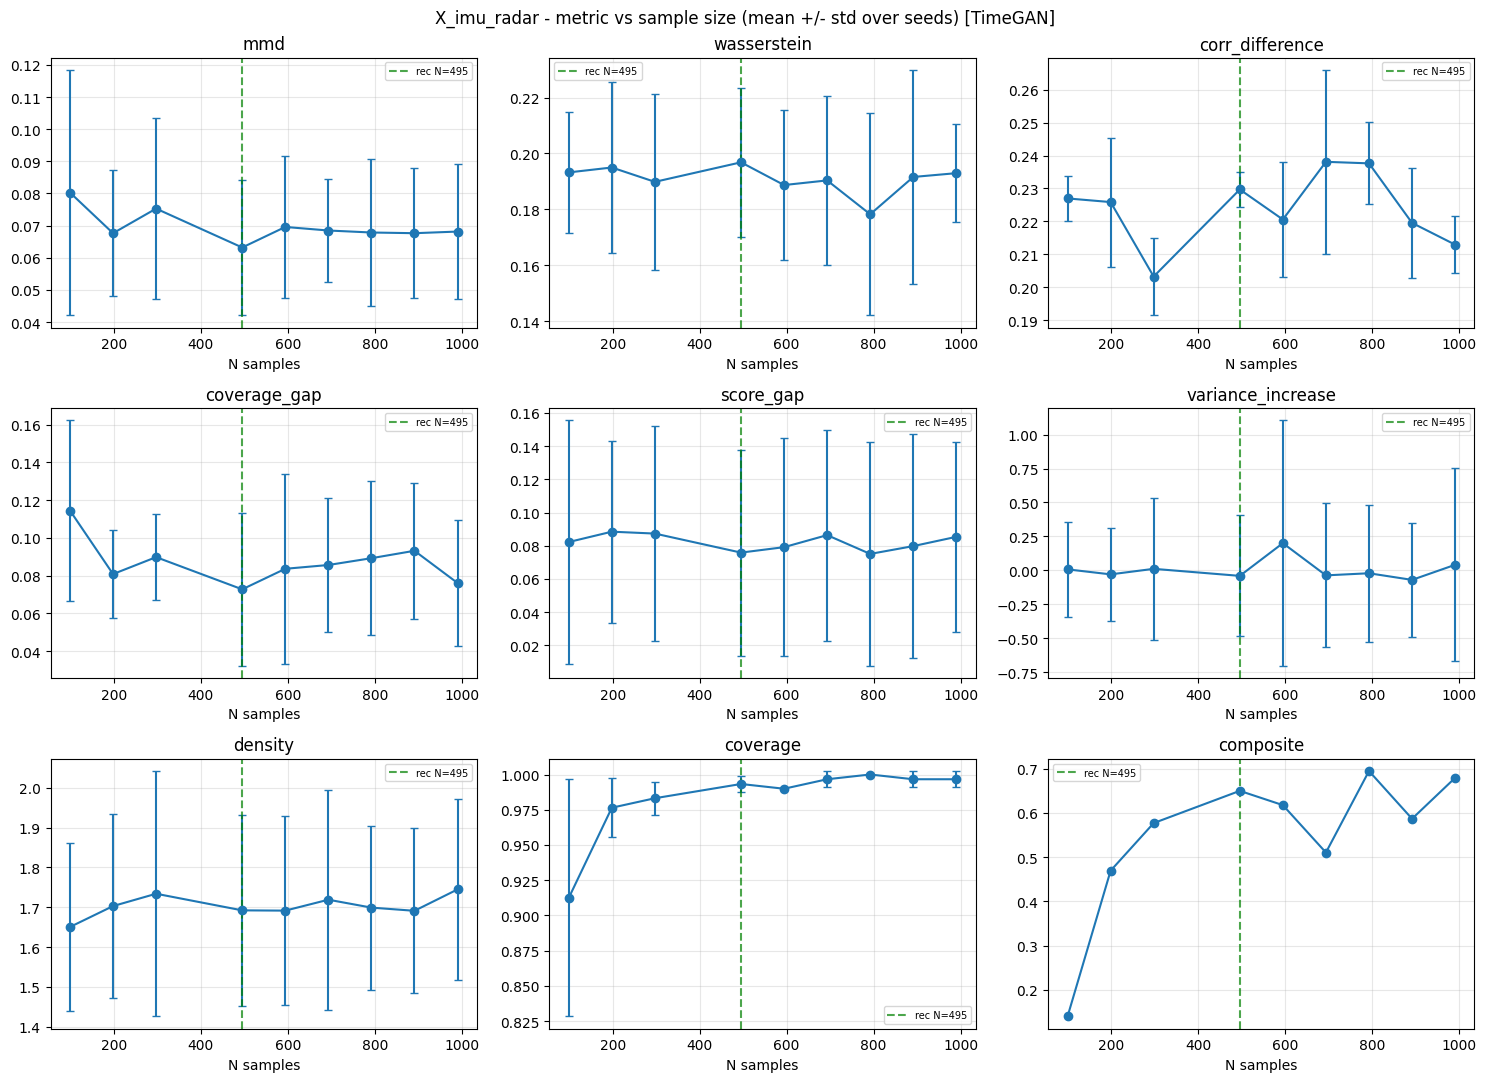

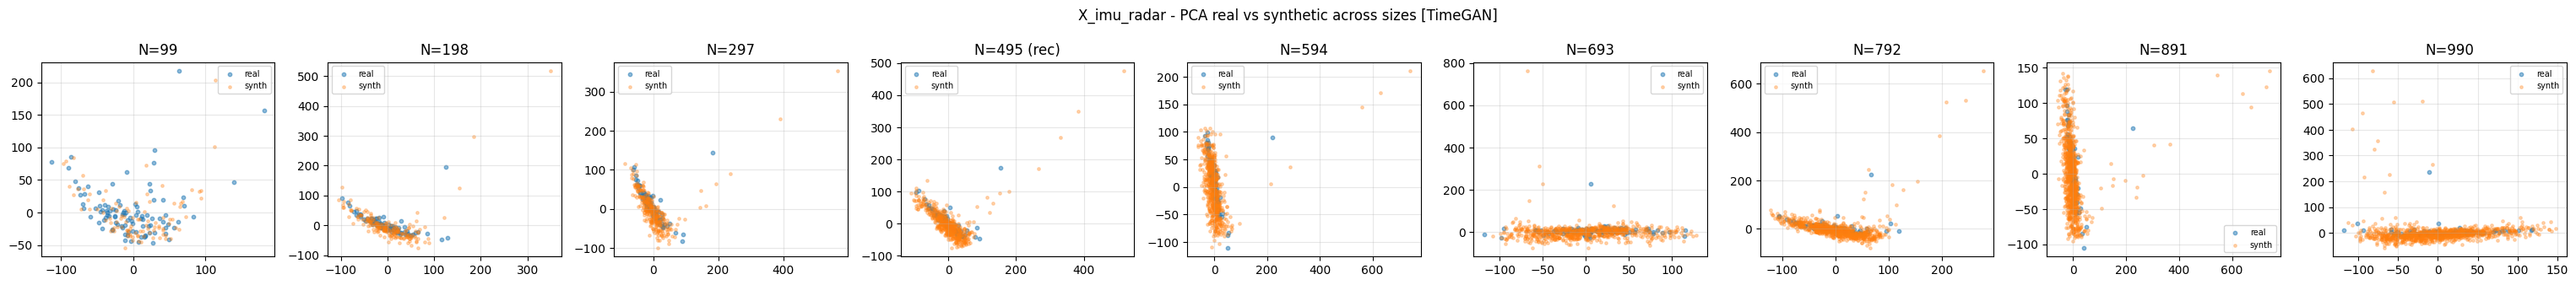

In [13]:
def plot_curves(name):
    sub=AGG[AGG.dataset==name].sort_values("N"); ss=AGG_STD[AGG_STD.dataset==name].sort_values("N")
    mets=["mmd","wasserstein","corr_difference","coverage_gap","score_gap","variance_increase","density","coverage","composite"]
    recN=REC[name]["N"]; fig,axes=plt.subplots(3,3,figsize=(15,11))
    for ax,mt in zip(axes.ravel(),mets):
        x=sub["N"].values; y=sub[mt].values
        yerr=ss[mt].values if mt in ss and mt!="composite" else None
        ax.errorbar(x,y,yerr=yerr,marker="o",capsize=3)
        ax.axvline(recN,color="green",ls="--",alpha=.7,label=f"rec N={recN}")
        ax.set_title(mt); ax.set_xlabel("N samples"); ax.grid(alpha=.3); ax.legend(fontsize=7)
    fig.suptitle(f"{name} - metric vs sample size (mean +/- std over seeds) [TimeGAN]")
    fig.tight_layout(); fig.savefig(CFG.output_dir/f"{name}_curves.png",dpi=110); plt.show(); plt.close(fig)

def plot_pca(name):
    Re=EMB[name]["Re"]; syn=EMB[name]["synth"]; sizes=sorted(syn)
    fig,axes=plt.subplots(1,len(sizes),figsize=(3.4*len(sizes),3.4),squeeze=False)
    for j,N in enumerate(sizes):
        allp=np.vstack([Re,syn[N]]); p=PCA(2,random_state=CFG.seed).fit_transform(allp)
        axes[0][j].scatter(*p[:len(Re)].T,s=10,alpha=.5,label="real")
        axes[0][j].scatter(*p[len(Re):].T,s=6,alpha=.3,label="synth")
        tag=" (rec)" if N==REC[name]["N"] else ""
        axes[0][j].set_title(f"N={N}{tag}"); axes[0][j].legend(fontsize=7); axes[0][j].grid(alpha=.3)
    fig.suptitle(f"{name} - PCA real vs synthetic across sizes [TimeGAN]"); fig.tight_layout()
    fig.savefig(CFG.output_dir/f"{name}_pca.png",dpi=110); plt.show(); plt.close(fig)

for name in RAW:
    plot_curves(name); plot_pca(name)

## 13. Save synthetic data at the recommended size + package

Saves the generation chain (`generator` / `supervisor` / `recovery` `.keras`) plus the fitted `Prep`, so a synthetic set can be regenerated later as `Z -> G -> S -> R -> prep.inverse`.

In [14]:
import shutil
for name in RAW:
    tgan,prep,latent,_=MODELS[name]; recN=REC[name]["N"]
    set_seeds(CFG.seed)
    synth=generate(tgan,prep,recN,CFG,latent)
    d=CFG.output_dir/name; d.mkdir(parents=True,exist_ok=True)
    np.save(d/"synthetic_recommended.npy",synth)
    with open(d/"prep.pkl","wb") as f: pickle.dump(prep,f)
    tgan.generator.save(d/"generator.keras")
    tgan.supervisor.save(d/"supervisor.keras")
    tgan.recovery.save(d/"recovery.keras")
    pd.DataFrame([{"dataset":name,"recommended_N":recN,"multiplier":REC[name]["multiplier"],
                   "n_features":prep.F_full,"modeled_dim":prep.K}]).to_csv(d/"metadata.csv",index=False)
    print(f"  {name:16s} saved {synth.shape} at recommended N={recN}")
arch=shutil.make_archive(str(CFG.output_dir),"zip",root_dir=str(CFG.output_dir))
print("\nZipped ->",arch)

  X_imu_radar      saved (495, 32, 1137) at recommended N=495

Zipped -> c:\Users\mabideen\Downloads\Data_Augmentation\Stage_2_Data_generation\exp_3\timegan_size_same_params.zip


## Reading the results

For each dataset the recommended N is the smallest size where fidelity (MMD / Wasserstein / correlation)
has flattened **and** diversity (coverage / variance increase) has stopped growing — i.e. more samples add
`< recommend_tol` composite quality. Beyond it you are paying compute for near-duplicates.

Caveats: with ~99 real samples the TimeGAN learns a temporal manifold, so a "recommended size" tells you how
much to draw before returns vanish, not how to exceed the data-scarcity ceiling. The knee is averaged over
`n_seeds` splits; raise `n_seeds` to 5 for a tighter estimate. The real reference here is the full real set
(consistent across sizes); the study measures **relative** saturation, not absolute fidelity.

Because outputs mirror Experiment 2 exactly (`timegan_size_study/cross_dataset_summary.csv` shares columns
with `vae_size_study/cross_dataset_summary.csv`), the two files can be diffed directly to compare the VAE
and TimeGAN augmenters per dataset. TimeGAN is heavier to train (3 phases x GRUs on CPU): for a quick smoke
test set `n_seeds=1` and small `embedding/supervised/joint_epochs` before the full run.

## 14. Repeated-run stability analysis — robust final recommendation

Sections 9-13 produce one recommendation per dataset from a single full
**Generation -> Evaluation -> Recommendation** pass. To measure how stable that
recommendation is, we now repeat the **entire existing pipeline** `N_REPEATS`
times as independent runs, reusing `run_sweep`, `aggregate` and `recommend`
**unchanged** — the existing evaluation stays the sole authority for each run's
recommendation. Each run gets its own seed offset (`CFG.seed + rep*REP_SEED_STRIDE`),
so the runs are independent yet fully reproducible; run 0 keeps the original
`CFG.seed`, so it reproduces the single-pass result and acts as an anchor.

For every dataset we then collect the per-run recommended multiplier, take the
**mean** across runs, and snap that mean to the **nearest multiplier actually
generated in the sweep grid** (`CFG.multipliers`). That snapped multiplier is the
robust final representative recommendation. *Example:* runs recommending
`x4, x6, x8, x5, x6` give mean `5.8`, whose nearest available multiplier is `x6`.

The robust final dataset is regenerated at the selected multiplier from the same
kept TimeGAN used in Section 13 (`MODELS[name]`, with `set_seeds(CFG.seed)`), so
only the *size* recommendation is made robust — the generator and methodology are
unchanged.

> **Compute note.** TimeGAN training is expensive, and every repetition retrains
> all `n_seeds` TimeGANs for all datasets (one repetition == one full sweep, i.e.
> roughly the wall-clock time Section 9 already took). Total time scales ~linearly
> with `N_REPEATS`, so with the default this is a long run — **lower `N_REPEATS`
> below** if you want a quicker pass.

All existing single-pass outputs are preserved untouched; the robust results are
written to new files (`*_repeated_final.npy`, `metadata_repeated.csv`,
`repeated_run_stability.csv`).

In [15]:
# --- Repeated-run stability configuration (change N_REPEATS to taste) ---
# NOTE: each repetition re-runs the full TimeGAN sweep (train n_seeds models per dataset,
# then generate + evaluate at every size), so runtime grows ~linearly with N_REPEATS and
# TimeGAN training is slow -- lower N_REPEATS for a faster pass.
N_REPEATS = 5          # number of independent Generation -> Evaluation -> Recommendation runs
REP_SEED_STRIDE = 1000  # seed spacing between runs (keeps each run's seed block independent)

print(f"Repeated-run analysis: {N_REPEATS} independent runs "
      f"(seeds {CFG.seed} + rep*{REP_SEED_STRIDE}), reusing the existing pipeline unchanged.")

Repeated-run analysis: 5 independent runs (seeds 42 + rep*1000), reusing the existing pipeline unchanged.


In [16]:
from dataclasses import replace as _dc_replace

# One record per dataset: the recommendation + full evaluation trace from every repetition.
REPEAT_RESULTS = {name: {"seeds": [], "rec_multiplier": [], "rec_N": [],
                         "composite_at_rec": [], "composite_grid": [],
                         "grid_multipliers": None, "grid_N": None,
                         "metric_frames": []} for name in RAW}

for rep in range(N_REPEATS):
    rep_seed = CFG.seed + rep * REP_SEED_STRIDE     # run 0 == CFG.seed -> reproduces the single pass
    cfg_rep = _dc_replace(CFG, seed=rep_seed)       # identical config, independent seed
    set_seeds(rep_seed)                             # keep global RNG state reproducible per run

    # ----- existing pipeline, executed exactly as-is (models are retrained internally) -----
    results_rep, _emb_rep, _models_rep = run_sweep(cfg_rep)      # Generation + Evaluation
    agg_rep, _agg_std_rep = aggregate(results_rep)              # Aggregate over seeds

    for name in RAW:
        sub = agg_rep[agg_rep.dataset == name].sort_values("N").reset_index(drop=True)
        C, recN, recM = recommend(sub, cfg_rep)                # Recommendation (unchanged authority)
        store = REPEAT_RESULTS[name]
        store["seeds"].append(rep_seed)
        store["rec_multiplier"].append(int(recM))
        store["rec_N"].append(int(recN))
        store["composite_at_rec"].append(float(C[sub["N"].values == recN][0]))
        store["composite_grid"].append(np.asarray(C, float))
        sub_c = sub.copy(); sub_c["composite"] = C; sub_c["rep"] = rep
        store["metric_frames"].append(sub_c)
        if store["grid_multipliers"] is None:
            store["grid_multipliers"] = sub["multiplier"].values.astype(int)
            store["grid_N"] = sub["N"].values.astype(int)

    del _emb_rep, _models_rep     # only recommendations/metrics are needed downstream; free memory

    print(f"  rep {rep + 1:>2}/{N_REPEATS} (seed {rep_seed}): "
          + ", ".join(f"{name}->{REPEAT_RESULTS[name]['rec_multiplier'][-1]}x" for name in RAW))

set_seeds(CFG.seed)   # restore the original global seed after the repeated runs
print(f"\nrepeated runs done: {N_REPEATS} x full pipeline over {len(RAW)} datasets")


=== X_imu_radar ((99, 32, 1137)) ===
  seed 42: trained 250 joint ep in 404s (K=32, dropped 294)
  seed 43: trained 250 joint ep in 406s (K=32, dropped 294)
  seed 44: trained 250 joint ep in 406s (K=32, dropped 294)
  rep  1/5 (seed 42): X_imu_radar->5x

=== X_imu_radar ((99, 32, 1137)) ===
  seed 1042: trained 250 joint ep in 410s (K=32, dropped 294)
  seed 1043: trained 250 joint ep in 407s (K=32, dropped 294)
  seed 1044: trained 250 joint ep in 411s (K=32, dropped 294)
  rep  2/5 (seed 1042): X_imu_radar->3x

=== X_imu_radar ((99, 32, 1137)) ===
  seed 2042: trained 250 joint ep in 411s (K=32, dropped 294)
  seed 2043: trained 250 joint ep in 413s (K=32, dropped 294)
  seed 2044: trained 250 joint ep in 387s (K=32, dropped 294)
  rep  3/5 (seed 2042): X_imu_radar->5x

=== X_imu_radar ((99, 32, 1137)) ===
  seed 3042: trained 250 joint ep in 421s (K=32, dropped 294)
  seed 3043: trained 250 joint ep in 417s (K=32, dropped 294)
  seed 3044: trained 250 joint ep in 417s (K=32, dropp

In [17]:
def _nearest_grid_multiplier(mean_val, grid):
    # nearest multiplier that was actually generated; ties resolve to the smaller (conservative) one
    grid = np.asarray(sorted(set(int(g) for g in grid)))
    return int(grid[int(np.argmin(np.abs(grid - float(mean_val))))])

REPEAT_SUMMARY_ROWS = []
REPEAT_FINAL = {}   # name -> robust final selection

for name in RAW:
    store = REPEAT_RESULTS[name]
    recs = np.asarray(store["rec_multiplier"], float)
    grid_mults = store["grid_multipliers"]; grid_N = store["grid_N"]

    mean_rec = float(recs.mean())                                  # mean recommendation across runs
    sel_mult = _nearest_grid_multiplier(mean_rec, grid_mults)      # snap to nearest generated multiplier
    sel_N = int(grid_N[list(grid_mults).index(sel_mult)])

    # mean composite (existing evaluation score) across runs at the selected multiplier
    comp_grid = np.vstack(store["composite_grid"])                 # (N_REPEATS, n_grid)
    gi = int(list(grid_mults).index(sel_mult))
    mean_comp_at_sel = float(comp_grid[:, gi].mean())

    # mean of the raw evaluation metrics across runs at the selected multiplier
    frames = pd.concat(store["metric_frames"], ignore_index=True)
    sel_metrics = frames[frames["multiplier"] == sel_mult].mean(numeric_only=True)

    REPEAT_FINAL[name] = {
        "mean_multiplier": mean_rec, "selected_multiplier": sel_mult, "selected_N": sel_N,
        "mean_composite_at_selected": mean_comp_at_sel,
        "per_rep_multipliers": [int(m) for m in store["rec_multiplier"]],
        "single_pass_multiplier": int(REC[name]["multiplier"]), "single_pass_N": int(REC[name]["N"]),
    }
    REPEAT_SUMMARY_ROWS.append({
        "dataset": name, "n_repeats": N_REPEATS,
        "per_rep_multipliers": " ".join(f"{m}x" for m in store["rec_multiplier"]),
        "mean_multiplier": round(mean_rec, 3), "selected_multiplier": f"{sel_mult}x",
        "selected_N": sel_N, "single_pass_multiplier": f"{REC[name]['multiplier']}x",
        "mean_composite_at_selected": round(mean_comp_at_sel, 4),
        "mmd": float(sel_metrics.get("mmd", np.nan)),
        "wasserstein": float(sel_metrics.get("wasserstein", np.nan)),
        "coverage": float(sel_metrics.get("coverage", np.nan)),
    })

REPEAT_SUMMARY = pd.DataFrame(REPEAT_SUMMARY_ROWS).set_index("dataset")
REPEAT_SUMMARY.to_csv(CFG.output_dir / "repeated_run_stability.csv")

# persist every per-run evaluation table too (all relevant evaluation results)
per_rep_all = pd.concat([f for name in RAW for f in REPEAT_RESULTS[name]["metric_frames"]],
                        ignore_index=True)
per_rep_all.to_csv(CFG.output_dir / "repeated_run_per_rep_metrics.csv", index=False)

print("################ REPEATED-RUN STABILITY SUMMARY ################")
display(REPEAT_SUMMARY)

################ REPEATED-RUN STABILITY SUMMARY ################


,n_repeats,per_rep_multipliers,mean_multiplier,selected_multiplier,selected_N,single_pass_multiplier,mean_composite_at_selected,mmd,wasserstein,coverage
dataset,,,,,,,,,,
X_imu_radar,5,5x 3x 5x 7x 6x,5.2000,5x,495,5x,0.6497,0.0690,0.1766,0.9892


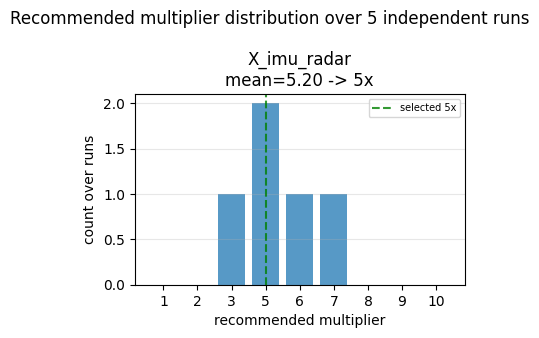

In [18]:
# distribution of the recommended multiplier over the independent runs (per dataset)
grid_all = sorted(set(int(m) for m in CFG.multipliers))
fig, axes = plt.subplots(1, len(RAW), figsize=(4.2 * len(RAW), 3.4), squeeze=False)
for ax, name in zip(axes[0], RAW):
    recs = REPEAT_RESULTS[name]["rec_multiplier"]
    counts = [recs.count(m) for m in grid_all]
    ax.bar([str(m) for m in grid_all], counts, alpha=.75)
    sel = REPEAT_FINAL[name]["selected_multiplier"]; mean_rec = REPEAT_FINAL[name]["mean_multiplier"]
    ax.axvline(grid_all.index(sel), color="green", ls="--", alpha=.8, label=f"selected {sel}x")
    ax.set_title(f"{name}\nmean={mean_rec:.2f} -> {sel}x")
    ax.set_xlabel("recommended multiplier"); ax.set_ylabel("count over runs")
    ax.grid(alpha=.3, axis="y"); ax.legend(fontsize=7)
fig.suptitle(f"Recommended multiplier distribution over {N_REPEATS} independent runs")
fig.tight_layout(); fig.savefig(CFG.output_dir / "repeated_run_stability.png", dpi=110)
plt.show(); plt.close(fig)

In [19]:
# Regenerate + save the robust final dataset at the selected multiplier, then report.
# Uses the same kept TimeGAN as Section 13 (MODELS[name]) so only the *size* is made robust;
# writes NEW filenames only -- the existing single-pass outputs are left untouched.
print("################ FINAL REPRESENTATIVE RECOMMENDATION (repeated-run) ################\n")
for name in RAW:
    fin = REPEAT_FINAL[name]
    sel_N = fin["selected_N"]; sel_mult = fin["selected_multiplier"]

    tgan, prep, latent, _ = MODELS[name]         # canonical kept model (same generator as Section 13)
    set_seeds(CFG.seed)                          # reproducible generation, matching Section 13
    synth = generate(tgan, prep, sel_N, CFG, latent)

    d = CFG.output_dir / name; d.mkdir(parents=True, exist_ok=True)
    final_path = d / "synthetic_repeated_final.npy"
    np.save(final_path, synth)
    pd.DataFrame([{
        "dataset": name, "n_repeats": N_REPEATS,
        "per_rep_multipliers": " ".join(f"{m}x" for m in fin["per_rep_multipliers"]),
        "mean_multiplier": fin["mean_multiplier"],
        "selected_multiplier": sel_mult, "selected_N": sel_N,
        "mean_composite_at_selected": fin["mean_composite_at_selected"],
        "single_pass_multiplier": fin["single_pass_multiplier"],
        "single_pass_N": fin["single_pass_N"],
        "n_features": prep.F_full, "modeled_dim": prep.K,
    }]).to_csv(d / "metadata_repeated.csv", index=False)

    print(f"=== {name} ===")
    print(f"  per-run recommendations : {' '.join(f'{m}x' for m in fin['per_rep_multipliers'])}")
    print(f"  mean recommendation     : {fin['mean_multiplier']:.3f}x")
    print(f"  selected robust final   : {sel_mult}x  (N={sel_N})")
    print(f"  single-pass baseline    : {fin['single_pass_multiplier']}x (N={fin['single_pass_N']})")
    print(f"  mean composite @ final  : {fin['mean_composite_at_selected']:.4f}")
    print(f"  final dataset saved     : {tuple(synth.shape)} -> {final_path}\n")

print("Existing single-pass outputs preserved. Robust final outputs written as")
print("  <dataset>/synthetic_repeated_final.npy, <dataset>/metadata_repeated.csv,")
print("  repeated_run_stability.csv, repeated_run_per_rep_metrics.csv, repeated_run_stability.png")
print("(The generator is the Section 13 kept TimeGAN, whose generator/supervisor/recovery.keras")
print(" and prep.pkl already exist.)")

################ FINAL REPRESENTATIVE RECOMMENDATION (repeated-run) ################

=== X_imu_radar ===
  per-run recommendations : 5x 3x 5x 7x 6x
  mean recommendation     : 5.200x
  selected robust final   : 5x  (N=495)
  single-pass baseline    : 5x (N=495)
  mean composite @ final  : 0.6497
  final dataset saved     : (495, 32, 1137) -> c:\Users\mabideen\Downloads\Data_Augmentation\Stage_2_Data_generation\exp_3\timegan_size_same_params\X_imu_radar\synthetic_repeated_final.npy

Existing single-pass outputs preserved. Robust final outputs written as
  <dataset>/synthetic_repeated_final.npy, <dataset>/metadata_repeated.csv,
  repeated_run_stability.csv, repeated_run_per_rep_metrics.csv, repeated_run_stability.png
(The generator is the Section 13 kept TimeGAN, whose generator/supervisor/recovery.keras
 and prep.pkl already exist.)
